# Use Real Images for Processing or Somethin

This notebook runs MPI-based image processing using C++ (CUDA + MPI + OpenMP).

We dynamically pass images into the parallel program and test performance across multiple processor counts.

but yea that how it works idk

In [1]:
import subprocess
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
print(os.getcwd())

c:\Users\nyoma\Downloads\mpyCUDA\CUDA-Speedup-Law


In [3]:
procs = [1, 2, 4, 6, 8, 16, 32, 48]
times = []

input_img = r"./images/input.jpg"
output_prefix = r"./images/output"

In [4]:
for p in procs:

    cmd = [
        r"C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe",
        "-n", str(p),
        r"./scripts/parallel_image.exe",
        input_img,
        f"{output_prefix}_{p}.jpg"
    ]

    print("Running:", " ".join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)

    out = subprocess.check_output(cmd).decode()

    print(out)

    t = float(re.findall(r"Time Taken ([0-9.]+)", out)[0])
    times.append(t)

times

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 1 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_1.jpg
Rank 0 started
Time Taken 0.213144
Finished rank 0


Rank 0 started
Time Taken 0.180885
Finished rank 0

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 2 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_2.jpg
Rank 1 started
Finished rank 1
Rank 0 started
Time Taken 0.177715
Finished rank 0


Rank 1 started
Finished rank 1
Rank 0 started
Time Taken 0.174373
Finished rank 0

Running: C:\Users\nyoma\scoop\apps\msmpi\10.1.1\mpiexec.exe -n 4 ./scripts/parallel_image.exe ./images/input.jpg ./images/output_4.jpg
Rank 1 started
Finished rank 1
Rank 3 started
Finished rank 3
Rank 2 started
Finished rank 2
Rank 0 started
Time Taken 0.282156
Finished rank 0


Rank 2 started
Finished rank 2
Rank 3 started
Finished rank 3
Rank 1 started
Finished rank 1
Rank 0 started
Time Taken 0.248685
Finished rank 0

Running: C:\Users\nyoma\scoop\ap

[0.180885, 0.174373, 0.248685, 0.333303, 0.412073, 0.839746, 1.73105, 2.76118]

In [5]:
times = np.array(times)
speedup = times[0] / times

speedup

array([1.        , 1.03734523, 0.72736594, 0.54270439, 0.43896348,
       0.21540442, 0.10449438, 0.06551004])

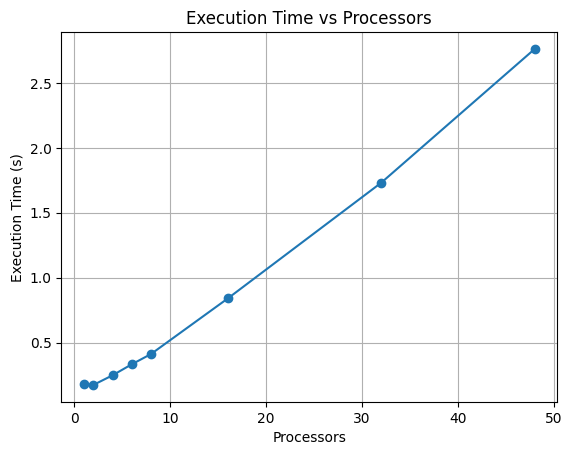

In [6]:
plt.figure()

plt.plot(procs, times, marker='o')
plt.xlabel("Processors")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Processors")

plt.grid()
plt.show()

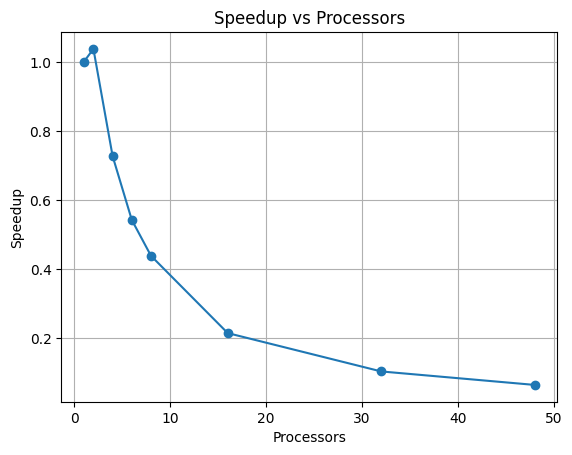

In [7]:
plt.figure()

plt.plot(procs, speedup, marker='o')

plt.xlabel("Processors")
plt.ylabel("Speedup")

plt.title("Speedup vs Processors")

plt.grid()
plt.show()